# Sprint 5 : Optimisation et Comparaison Finale

**AquaSense AI** (execution locale CPU)

Objectifs :
1. Tableau comparatif final (ML + DL)
2. Ensembles (Voting RF + XGB)
3. Ajustement du seuil pour `needs repair`
4. Selection du modele champion


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import f1_score, precision_recall_curve

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
REPORTS_DIR = PROJECT_ROOT / "reports"
from src.train import NEEDS_REPAIR, train_sprint5_final

sns.set_theme(style="whitegrid")


## 1. Entrainement Sprint 5 et tableau ML + DL

In [2]:
results = train_sprint5_final(save=True)
comparison_df = pd.DataFrame(results["comparison"]).sort_values(
    "f1_macro", ascending=False
)
comparison_df.head(15)



=== Sprint 5 — entraînement modèles clés (params S3) ===
  Random Forest tuned...


  XGBoost tuned...


  Recall champion (XGB SMOTE + seuil)...


    Seuil calibré : 0.16
  Soft Voting RF + XGB...


  RF F1=0.6658 | XGB F1=0.6570 | Voting F1=0.6710 | Recall champ F1=0.6289 (recall NR=0.6952)

=== Champion F1-Macro : voting_rf_xgb_soft (0.6710) ===
=== Champion recall métier : xgboost_smote_threshold (0.6952) ===

Voting RF+XGB égale ou bat le RF seul sur F1 — déploiement dashboard : recall champion pour alertes, voting ou RF pour F1.



Metriques -> C:\Users\MOH\Documents\AquaSense_AI\reports\sprint_05_metrics.json
Tableau  -> C:\Users\MOH\Documents\AquaSense_AI\reports\sprint_05_final_comparison.csv
Modeles  -> C:\Users\MOH\Documents\AquaSense_AI\models


,model,type,f1_macro,f1_needs_repair,recall_needs_repair,accuracy,roc_auc,latency_ms
0,voting_rf_xgb_soft,ML,0.670999,0.440601,0.560834,0.756145,0.884356,0.046395
1,random_forest_tuned,ML,0.665796,0.425013,0.484357,0.758586,0.872354,0.103526
2,random_forest,ML,0.665796,0.425013,0.484357,0.758586,0.872354,0.032590
3,xgboost_tuned,ML,0.657027,0.433659,0.641947,0.734259,0.877377,0.019403
4,xgboost,ML,0.655363,0.434886,0.638470,0.731902,0.873131,0.014389
5,xgboost_smote_recall_boost,ML,0.653761,0.417112,0.451912,0.748906,0.869452,0.015904
6,random_forest_smote_recall_boost,ML,0.651140,0.394707,0.397451,0.755135,0.863449,0.021727
7,xgboost_threshold_recall_boost,ML,0.639195,0.407746,0.670915,0.714310,0.870862,0.008557
8,random_forest_smote_threshold_recall_boost,ML,0.631662,0.384562,0.646582,0.711616,0.863449,0.018122
9,xgboost_smote_threshold_recall_boost,ML,0.628868,0.392670,0.695249,0.703283,0.869452,0.008875


## 2. Detail architectures DL (resultats Colab archives)

In [3]:
dl_csv = REPORTS_DIR / "sprint_04_dl_comparison.csv"
if dl_csv.exists():
    dl_df = pd.read_csv(dl_csv).sort_values("f1_macro", ascending=False)
    print(dl_df.to_string())
else:
    print("Pas de CSV DL : executer 05_dl_colab_tune.ipynb sur Colab.")


     architecture  f1_macro  f1_needs_repair  recall_needs_repair  accuracy deployable
0    mlp_l2_0.001    0.5410           0.3113               0.6025    0.6099        yes
1    mlp_baseline    0.5297           0.2992               0.5666    0.6038        yes
2    residual_mlp    0.5276           0.2743               0.3024    0.6341        yes
3      mlp_l2_0.0    0.5272           0.2973               0.5747    0.5984        yes
4           cnn1d    0.4113           0.1726               0.2260    0.5067        yes
5  mlp_tuned_grid    0.3817           0.2065               0.9305    0.3803         no


## 3. Ajustement du seuil de decision (`needs repair`)

Analyse sur le champion recall (XGB SMOTE + seuil).

 Seuil  F1 needs repair  F1 Macro
  0.30         0.420915  0.649553
  0.35         0.423785  0.652924
  0.40         0.418989  0.653036
  0.45         0.422089  0.655223
  0.50         0.412493  0.653288


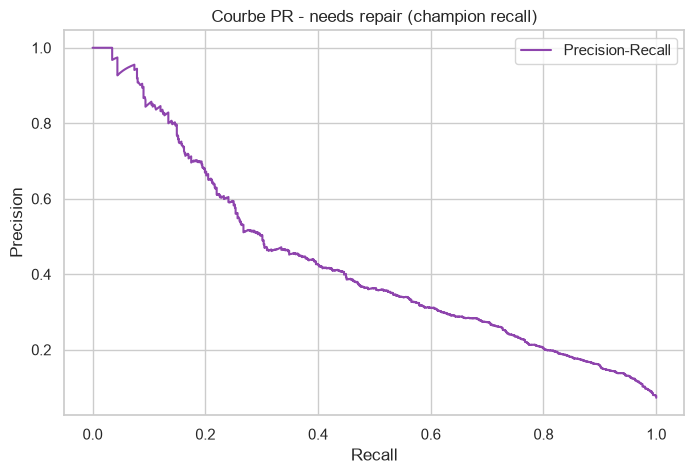

In [4]:
recall_est = results["trained"]["recall"]
from src.train import CLASS_ORDER, get_feature_matrix, load_training_data, stratified_split

df = load_training_data()
X, y = get_feature_matrix(df)
_, X_test, _, y_test = stratified_split(X, y)

probas = recall_est.predict_proba(X_test)
classes = list(CLASS_ORDER)
idx_repair = classes.index(NEEDS_REPAIR)
p_repair = probas[:, idx_repair]
y_true_repair = (y_test == NEEDS_REPAIR).astype(int)

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]
rows = []
for th in thresholds:
    preds = []
    for row in probas:
        if row[idx_repair] >= th:
            preds.append(NEEDS_REPAIR)
        else:
            tmp = row.copy()
            tmp[idx_repair] = 0.0
            preds.append(classes[int(np.argmax(tmp))])
    f1_per = f1_score(y_test, preds, average=None, labels=classes)
    f1_nr = f1_per[classes.index(NEEDS_REPAIR)]
    f1_macro = f1_score(y_test, preds, average="macro")
    rows.append((th, f1_nr, f1_macro))

th_df = pd.DataFrame(rows, columns=["Seuil", "F1 needs repair", "F1 Macro"])
print(th_df.to_string(index=False))

precision, recall, _ = precision_recall_curve(y_true_repair, p_repair)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label="Precision-Recall", color="#8e44ad")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Courbe PR - needs repair (champion recall)")
plt.legend()
plt.show()


## 4. Selection du modele de production

Deux champions : F1-Macro (analytics) et recall `needs repair` (alertes terrain).

Voir `reports/model_card.md` et `reports/sprint_05_metrics.json`.

In [5]:
print("Champions Sprint 5 :")
for k, v in results["champions"].items():
    print(f"  {k}: {v}")
print("\nRecommandation :", results["recommendation"])


Champions Sprint 5 :
  f1_macro: {'model': 'voting_rf_xgb_soft', 'score': 0.6709989185219726}
  recall_needs_repair: {'model': 'xgboost_smote_threshold', 'score': 0.6952491309385863}
  production_dashboard_alerts: xgboost_smote_threshold
  production_analytics_f1: voting_rf_xgb_soft

Recommandation : Voting RF+XGB égale ou bat le RF seul sur F1 — déploiement dashboard : recall champion pour alertes, voting ou RF pour F1.
